#Severity Estimation Model

##Model Training

In [2]:
!pip -q install xgboost joblib -q

In [13]:
# -----------------------------
# 1) Imports
# -----------------------------
import numpy as np
import pandas as pd
import joblib
import io

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import files

# =========================================================
# 2) UPLOAD CRIME DATASET CSV
# =========================================================
print("Upload your crime dataset CSV file")
uploaded = files.upload()

crime_file_name = list(uploaded.keys())[0]
crime_df = pd.read_csv(io.BytesIO(uploaded[crime_file_name]))

print(f"\nLoaded crime dataset: {crime_file_name}")
print("Shape:", crime_df.shape)
display(crime_df.head())

# =========================================================
# 3) PASTE HOTSPOT MODULE OUTPUT HERE
# =========================================================
# Replace this with your actual hotspot output dictionary

hotspot_output = {
    'crime_type': 'drugs',
    'predictions': [
        {'gn_encoded': 31, 'gn_name': 'LK2130145', 'risk_score': 0.690627464125749},
        {'gn_encoded': 26, 'gn_name': 'LK2130120', 'risk_score': 0.6855819646885483},
        {'gn_encoded': 29, 'gn_name': 'LK2130135', 'risk_score': 0.6193563941259294},
        {'gn_encoded': 45, 'gn_name': 'LK2130225', 'risk_score': 0.2174290193243538},
        {'gn_encoded': 14, 'gn_name': 'LK2130050', 'risk_score': 0.19376851459277794},
        {'gn_encoded': 15, 'gn_name': 'LK2130060', 'risk_score': 0.16877401704051118},
        {'gn_encoded': 46, 'gn_name': 'LK2130230', 'risk_score': 0.16483895818288932},
        {'gn_encoded': 42, 'gn_name': 'LK2130205', 'risk_score': 0.14702907557080766},
        {'gn_encoded': 25, 'gn_name': 'LK2130115', 'risk_score': 0.1358890409691473},
        {'gn_encoded': 20, 'gn_name': 'LK2130085', 'risk_score': 0.13406519136808503}
    ],
    'status': 'success'
}

# =========================================================
# 4) CONFIG
# =========================================================
TOTAL_AVAILABLE_OFFICERS = 120
RANDOM_SEED = 42
TEST_SIZE = 0.2
NOISE_STD = 0.03

# Output file names
RESOURCE_INPUT_OUTPUT = "resource_allocation_input.csv"
SYNTHETIC_DATA_OUTPUT = "resource_allocation_with_synthetic_target.csv"
RESULTS_OUTPUT = "resource_allocation_results.csv"
FEATURE_IMPORTANCE_OUTPUT = "resource_feature_importance.csv"
MODEL_OUTPUT = "resource_allocation_xgboost_model.pkl"
FEATURES_OUTPUT = "resource_model_features.pkl"

# Crime severity weights
severity_weights = {
    "drugs": 1.2,
    "robbery": 1.5,
    "theft": 1.0,
    "vehicle theft": 1.25,
    "vehical theft": 1.25,  # typo-safe
    "burglary": 1.3,
    "buglary": 1.3,         # typo-safe
    "stabbing": 1.7
}

# =========================================================
# 5) HELPER FUNCTIONS
# =========================================================
def minmax(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    s_min = s.min()
    s_max = s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s_min) / (s_max - s_min)

def safe_fill_median(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        med = df[col].median()
        if pd.isna(med):
            med = 0
        df[col] = df[col].fillna(med)
    return df

def is_night_time(val):
    try:
        t = str(val).strip()
        hour = int(t.split(":")[0])
        return 1 if (hour >= 18 or hour < 6) else 0
    except:
        return np.nan

def allocate_integer_officers(df, score_col, total_officers, output_col="officers_allocated"):
    df = df.copy()

    total_score = df[score_col].sum()
    if not np.isfinite(total_score) or total_score <= 0:
        df[output_col] = 0
        return df

    df["officers_allocated_raw"] = (df[score_col] / total_score) * total_officers
    df[output_col] = np.floor(df["officers_allocated_raw"]).astype(int)

    assigned = int(df[output_col].sum())
    remaining = int(total_officers - assigned)

    if remaining > 0:
        df["fractional_part"] = df["officers_allocated_raw"] - df[output_col]
        top_idx = df.sort_values("fractional_part", ascending=False).head(remaining).index
        df.loc[top_idx, output_col] += 1

    return df

# =========================================================
# 6) VALIDATE REQUIRED COLUMNS
# =========================================================
required_cols = [
    "gn_division",
    "gn_pcode",
    "gn_population",
    "gn_distance_m",
    "Avg_Household_Income",
    "Unemployment_Rate",
    "Building_Density",
    "Road_Density",
    "Land_Area_Density"
]

missing = [c for c in required_cols if c not in crime_df.columns]
if missing:
    raise ValueError(f"Crime dataset missing required columns: {missing}")

# =========================================================
# 7) CLEAN CRIME DATA
# =========================================================
crime_df["gn_pcode"] = crime_df["gn_pcode"].astype(str).str.strip()
crime_df["gn_division"] = crime_df["gn_division"].astype(str).str.strip()

numeric_cols = [
    "gn_population",
    "gn_distance_m",
    "Avg_Household_Income",
    "Unemployment_Rate",
    "Building_Density",
    "Road_Density",
    "Land_Area_Density"
]

crime_df = safe_fill_median(crime_df, numeric_cols)

crime_df["gn_population"] = crime_df["gn_population"].clip(lower=1)
crime_df["gn_distance_m"] = crime_df["gn_distance_m"].clip(lower=0)

if "victim_age" in crime_df.columns:
    crime_df["victim_age"] = pd.to_numeric(crime_df["victim_age"], errors="coerce")

if "is_holiday" in crime_df.columns:
    crime_df["is_holiday"] = pd.to_numeric(crime_df["is_holiday"], errors="coerce").fillna(0)

if "date" in crime_df.columns:
    crime_df["date"] = pd.to_datetime(crime_df["date"], errors="coerce")

print("\nCrime data cleaned.")
display(crime_df.head())

# =========================================================
# 8) AGGREGATE TO GN LEVEL
# =========================================================
agg_dict = {
    "gn_population": "first",
    "gn_distance_m": "first",
    "Avg_Household_Income": "first",
    "Unemployment_Rate": "first",
    "Building_Density": "first",
    "Road_Density": "first",
    "Land_Area_Density": "first"
}

gn_df = crime_df.groupby(["gn_pcode", "gn_division"], as_index=False).agg(agg_dict)

# Historical crime count
crime_count_df = crime_df.groupby("gn_pcode").size().reset_index(name="historical_crime_count")
gn_df = gn_df.merge(crime_count_df, on="gn_pcode", how="left")

# Crime type diversity
if "crime" in crime_df.columns:
    crime_type_diversity_df = (
        crime_df.groupby("gn_pcode")["crime"]
        .nunique()
        .reset_index(name="crime_type_diversity")
    )
    gn_df = gn_df.merge(crime_type_diversity_df, on="gn_pcode", how="left")
else:
    gn_df["crime_type_diversity"] = 0

# Holiday crime ratio
if "is_holiday" in crime_df.columns:
    holiday_ratio_df = (
        crime_df.groupby("gn_pcode")["is_holiday"]
        .mean()
        .reset_index(name="holiday_crime_ratio")
    )
    gn_df = gn_df.merge(holiday_ratio_df, on="gn_pcode", how="left")
else:
    gn_df["holiday_crime_ratio"] = 0

# Night crime ratio
if "time" in crime_df.columns:
    crime_df["is_night_crime"] = crime_df["time"].apply(is_night_time)
    night_ratio_df = (
        crime_df.groupby("gn_pcode")["is_night_crime"]
        .mean()
        .reset_index(name="night_crime_ratio")
    )
    gn_df = gn_df.merge(night_ratio_df, on="gn_pcode", how="left")
else:
    gn_df["night_crime_ratio"] = 0

# Average victim age
if "victim_age" in crime_df.columns:
    victim_age_df = (
        crime_df.groupby("gn_pcode")["victim_age"]
        .mean()
        .reset_index(name="avg_victim_age")
    )
    gn_df = gn_df.merge(victim_age_df, on="gn_pcode", how="left")
else:
    gn_df["avg_victim_age"] = 0

optional_numeric_cols = [
    "historical_crime_count",
    "crime_type_diversity",
    "holiday_crime_ratio",
    "night_crime_ratio",
    "avg_victim_age"
]

gn_df = safe_fill_median(gn_df, optional_numeric_cols)

print("\nGN-level dataset created.")
print("Shape:", gn_df.shape)
display(gn_df.head())

# =========================================================
# 9) CONVERT HOTSPOT OUTPUT TO DATAFRAME
# =========================================================
if hotspot_output.get("status") != "success":
    raise ValueError("Hotspot output status is not success")

hotspot_df = pd.DataFrame(hotspot_output["predictions"])

hotspot_df = hotspot_df.rename(columns={
    "gn_name": "gn_pcode",
    "risk_score": "risk_score_next_week"
})

hotspot_df["gn_pcode"] = hotspot_df["gn_pcode"].astype(str).str.strip()
hotspot_df["risk_score_next_week"] = pd.to_numeric(
    hotspot_df["risk_score_next_week"], errors="coerce"
).fillna(0)

hotspot_df["risk_score_next_week"] = hotspot_df["risk_score_next_week"].clip(0, 1)
hotspot_df["crime_type"] = hotspot_output.get("crime_type", "unknown")

hotspot_df = hotspot_df[["gn_pcode", "crime_type", "risk_score_next_week"]]

print("\nHotspot dataframe created.")
display(hotspot_df.head())

# =========================================================
# 10) MERGE GN FEATURES + HOTSPOT RISK
# =========================================================
resource_input = gn_df.merge(hotspot_df, on="gn_pcode", how="left")

# Fill missing hotspot outputs
resource_input["crime_type"] = resource_input["crime_type"].fillna(
    hotspot_output.get("crime_type", "unknown")
)
resource_input["risk_score_next_week"] = resource_input["risk_score_next_week"].fillna(0.0)

# Save input dataset
resource_input.to_csv(RESOURCE_INPUT_OUTPUT, index=False)

print(f"\nMerged resource input saved as: {RESOURCE_INPUT_OUTPUT}")
print("Shape:", resource_input.shape)
display(resource_input.head())

# =========================================================
# 11) GENERATE NON-LINEAR SYNTHETIC TARGET
# =========================================================
df = resource_input.copy()

# Normalized factors
df["risk_factor"] = minmax(df["risk_score_next_week"])
df["pop_factor"] = minmax(np.log1p(df["gn_population"]))
df["distance_factor"] = minmax(df["gn_distance_m"])
df["building_factor"] = minmax(df["Building_Density"])
df["road_factor"] = minmax(df["Road_Density"])
df["unemployment_factor"] = minmax(df["Unemployment_Rate"])
df["income_inverse_factor"] = 1 - minmax(df["Avg_Household_Income"])
df["history_factor"] = minmax(df["historical_crime_count"])
df["night_factor"] = minmax(df["night_crime_ratio"])
df["diversity_factor"] = minmax(df["crime_type_diversity"])
df["high_risk_bonus"] = np.where(df["risk_factor"] > 0.65, 0.12, 0.0)
df["remote_area_bonus"] = np.where(df["distance_factor"] > 0.60, 0.08, 0.0)


# Crime severity
df["crime_severity"] = (
    df["crime_type"].astype(str).str.lower().map(severity_weights).fillna(1.0)
)

# Nonlinear / interaction terms
df["risk_pop_interaction"] = df["risk_factor"] * df["pop_factor"]
df["risk_distance_interaction"] = df["risk_factor"] * df["distance_factor"]
df["urban_pressure"] = df["building_factor"] * df["road_factor"]
df["socioeconomic_pressure"] = df["unemployment_factor"] * df["income_inverse_factor"]
df["history_night_interaction"] = df["history_factor"] * df["night_factor"]

# Random noise
np.random.seed(RANDOM_SEED)
noise = np.random.normal(0, 0.04, len(df))

# Nonlinear synthetic demand score
df["officer_demand_score_raw"] = (
    (
        0.18 * (df["risk_factor"] ** 2) +
        0.10 * np.sqrt(df["pop_factor"] + 1e-6) +
        0.08 * np.log1p(df["distance_factor"] + 1e-6) +
        0.10 * df["urban_pressure"] +
        0.08 * df["socioeconomic_pressure"] +
        0.14 * df["risk_pop_interaction"] +
        0.10 * df["risk_distance_interaction"] +
        0.10 * (df["history_factor"] ** 2) +
        0.06 * df["history_night_interaction"] +
        0.06 * df["diversity_factor"] +
        df["high_risk_bonus"] +
        df["remote_area_bonus"]
    ) * df["crime_severity"]
    + noise
)

df["officer_demand_score_raw"] = df["officer_demand_score_raw"].clip(lower=0)
df["officer_demand_score"] = minmax(df["officer_demand_score_raw"])

# Save dataset with synthetic target
df.to_csv(SYNTHETIC_DATA_OUTPUT, index=False)

print(f"\nSynthetic target generated and saved as: {SYNTHETIC_DATA_OUTPUT}")
display(df[[
    "gn_pcode",
    "gn_division",
    "crime_type",
    "risk_score_next_week",
    "crime_severity",
    "officer_demand_score"
]].head())

# =========================================================
# 12) TRAIN XGBOOST MODEL
# =========================================================
feature_cols = [
    "risk_score_next_week",
    "gn_population",
    "gn_distance_m",
    "Avg_Household_Income",
    "Unemployment_Rate",
    "Building_Density",
    "Road_Density",
    "Land_Area_Density",
    "historical_crime_count",
    "crime_type_diversity",
    "holiday_crime_ratio",
    "night_crime_ratio"
]

X = df[feature_cols].copy()
y = df["officer_demand_score"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=RANDOM_SEED
)

model.fit(X_train, y_train)

# Save model and features
joblib.dump(model, MODEL_OUTPUT)
joblib.dump(feature_cols, FEATURES_OUTPUT)

print(f"\nModel saved as: {MODEL_OUTPUT}")
print(f"Feature list saved as: {FEATURES_OUTPUT}")

# =========================================================
# 13) EVALUATE MODEL
# =========================================================
pred_test = np.clip(model.predict(X_test), 0, 1)

print("\n=== MODEL EVALUATION ===")
print("MAE:", mean_absolute_error(y_test, pred_test))
print("R2 :", r2_score(y_test, pred_test))

# =========================================================
# 14) PREDICT DEMAND FOR ALL GN DIVISIONS
# =========================================================
df["predicted_demand_score"] = np.clip(model.predict(X), 0, 1)

# =========================================================
# 15) ALLOCATE OFFICERS
# =========================================================
df = allocate_integer_officers(
    df,
    score_col="predicted_demand_score",
    total_officers=TOTAL_AVAILABLE_OFFICERS,
    output_col="officers_allocated"
)

df["allocation_rank"] = df["predicted_demand_score"].rank(
    ascending=False, method="dense"
).astype(int)

# =========================================================
# 16) FEATURE IMPORTANCE
# =========================================================
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.to_csv(FEATURE_IMPORTANCE_OUTPUT, index=False)

print(f"\nFeature importance saved as: {FEATURE_IMPORTANCE_OUTPUT}")
display(importance_df)

# =========================================================
# 17) FINAL RESULTS
# =========================================================
result_cols = [
    "gn_pcode",
    "gn_division",
    "crime_type",
    "risk_score_next_week",
    "historical_crime_count",
    "predicted_demand_score",
    "officers_allocated",
    "allocation_rank"
]

result_df = df[result_cols].sort_values(
    ["allocation_rank", "predicted_demand_score"],
    ascending=[True, False]
)

result_df.to_csv(RESULTS_OUTPUT, index=False)

print(f"\nFinal results saved as: {RESULTS_OUTPUT}")
print("\n=== TOP 20 RESOURCE ALLOCATIONS ===")
display(result_df.head(20))

print(f"Total officers allocated: {result_df['officers_allocated'].sum()} / {TOTAL_AVAILABLE_OFFICERS}")

# =========================================================
# 18) DOWNLOAD ALL OUTPUT FILES
# =========================================================
files.download(RESOURCE_INPUT_OUTPUT)
files.download(SYNTHETIC_DATA_OUTPUT)
files.download(RESULTS_OUTPUT)
files.download(FEATURE_IMPORTANCE_OUTPUT)
files.download(MODEL_OUTPUT)
files.download(FEATURES_OUTPUT)



Upload your crime dataset CSV file


Saving CrimeData_Final.csv to CrimeData_Final (3).csv

Loaded crime dataset: CrimeData_Final (3).csv
Shape: (1608, 24)


,crime_id,crime,location,date,sex,victim_ethnicity,victim_age,time,weather,latitude,...,gn_division,gn_pcode,gn_population,gn_distance_m,DS_Division,Avg_Household_Income,Unemployment_Rate,Building_Density,Road_Density,Land_Area_Density
0,1,burglary,mulgampola,12/31/2019,f,muslim,54,8:17:00,Cloudy,7.280544,...,Welata,LK2130170,21826,311.8,Gangawata Korale,124797,4.55,740.9,29.5,16.06
1,2,burglary,car park,1/4/2020,m,sinhala,42,2:00:00,Rainy,7.283445,...,Katukele West,LK2130105,8913,352.4,Gangawata Korale,111768,4.53,892.7,29.8,19.76
2,3,theft,bus stand,1/8/2020,f,sinhala,20,21:01:00,Rainy,7.256425,...,Penideniya,LK2139135,16411,518.6,Udunuwara,69786,5.57,548.4,16.6,11.66
3,4,vehicle theft,aniwatte,1/10/2020,m,sinhala,29,12:10:00,Cloudy,7.290058,...,Aniwatta East,LK2130100,1107,381.5,Gangawata Korale,107410,4.68,881.2,24.1,17.18
4,5,robbery,dutugamunu mawatha,1/11/2020,m,sinhala,59,2:39:00,Rainy,7.312344,...,Aruppala East,LK2130050,1293,322.6,Gangawata Korale,120663,4.71,585.4,24.0,9.45



Crime data cleaned.


,crime_id,crime,location,date,sex,victim_ethnicity,victim_age,time,weather,latitude,...,gn_division,gn_pcode,gn_population,gn_distance_m,DS_Division,Avg_Household_Income,Unemployment_Rate,Building_Density,Road_Density,Land_Area_Density
0,1,burglary,mulgampola,2019-12-31,f,muslim,54,8:17:00,Cloudy,7.280544,...,Welata,LK2130170,21826,311.8,Gangawata Korale,124797,4.55,740.9,29.5,16.06
1,2,burglary,car park,2020-01-04,m,sinhala,42,2:00:00,Rainy,7.283445,...,Katukele West,LK2130105,8913,352.4,Gangawata Korale,111768,4.53,892.7,29.8,19.76
2,3,theft,bus stand,2020-01-08,f,sinhala,20,21:01:00,Rainy,7.256425,...,Penideniya,LK2139135,16411,518.6,Udunuwara,69786,5.57,548.4,16.6,11.66
3,4,vehicle theft,aniwatte,2020-01-10,m,sinhala,29,12:10:00,Cloudy,7.290058,...,Aniwatta East,LK2130100,1107,381.5,Gangawata Korale,107410,4.68,881.2,24.1,17.18
4,5,robbery,dutugamunu mawatha,2020-01-11,m,sinhala,59,2:39:00,Rainy,7.312344,...,Aruppala East,LK2130050,1293,322.6,Gangawata Korale,120663,4.71,585.4,24.0,9.45


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# =========================================================
# COMPARE MULTIPLE REGRESSION MODELS
# FOR RESOURCE ALLOCATION MODEL
# =========================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ---------------------------------------------------------
# ASSUMPTION:
# You already have a dataframe called df
# and it already contains the synthetic target:
#   officer_demand_score
# ---------------------------------------------------------

# Feature columns
feature_cols = [
    "risk_score_next_week",
    "gn_population",
    "gn_distance_m",
    "Avg_Household_Income",
    "Unemployment_Rate",
    "Building_Density",
    "Road_Density",
    "Land_Area_Density",
    "historical_crime_count",
    "crime_type_diversity",
    "holiday_crime_ratio",
    "night_crime_ratio"
]

target_col = "officer_demand_score"

# Prepare X and y
X = df[feature_cols].copy()
y = df[target_col].copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
}

# Store results
results = []

# Store predictions if you want to inspect later
all_predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    # keep scores in valid range
    pred = np.clip(pred, 0, 1)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

    all_predictions[name] = pred

# Results table
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)

print("=== MODEL COMPARISON RESULTS ===")
display(results_df)

=== MODEL COMPARISON RESULTS ===


,Model,MAE,MSE,RMSE,R2
3,XGBoost,0.052747,0.004073,0.063822,0.902299
0,Linear Regression,0.066620,0.006875,0.082914,0.835100
2,Random Forest,0.053808,0.007436,0.086231,0.821644
1,Decision Tree,0.084771,0.012909,0.113620,0.690352


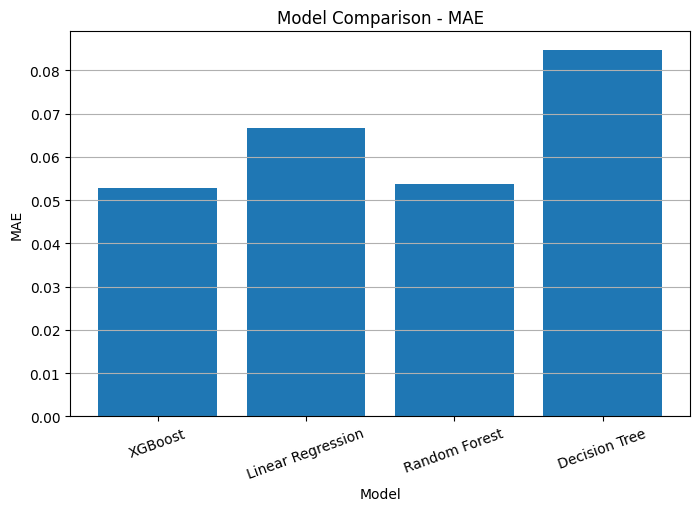

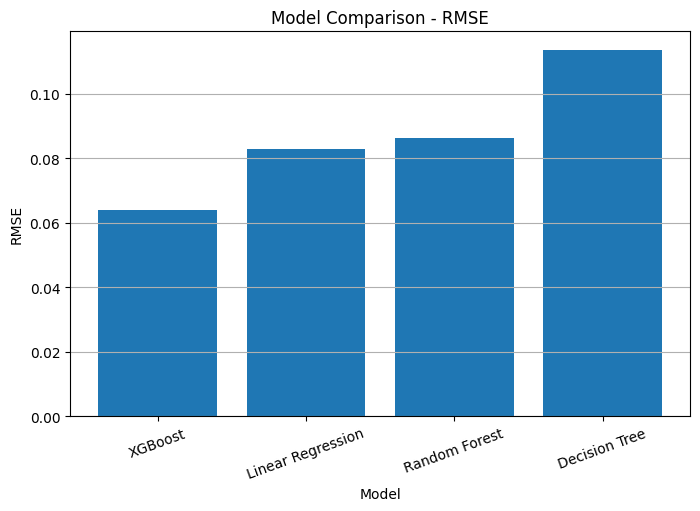

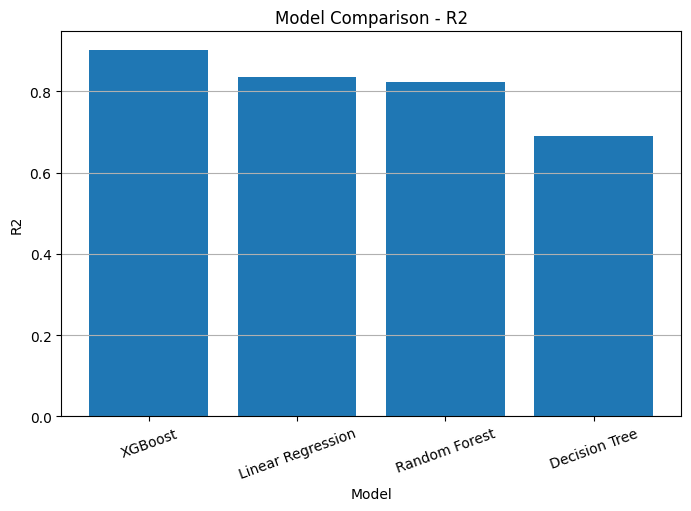

In [15]:
# =========================================================
# BAR CHARTS FOR MODEL COMPARISON
# =========================================================

metrics = ["MAE", "RMSE", "R2"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(results_df["Model"], results_df[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y")
    plt.show()

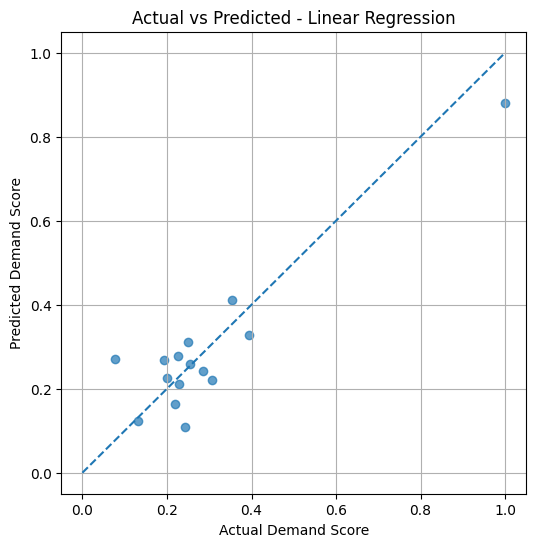

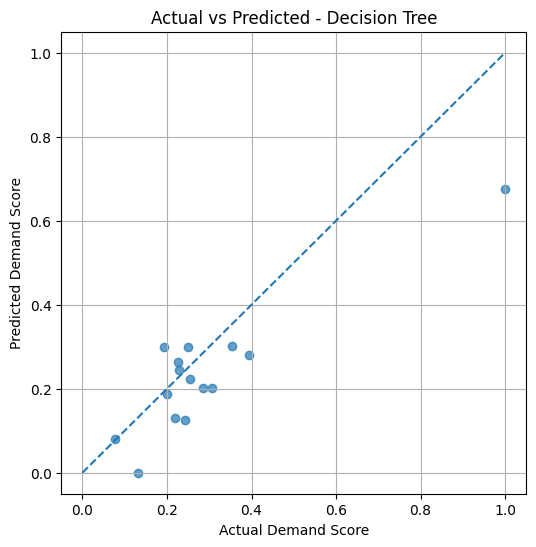

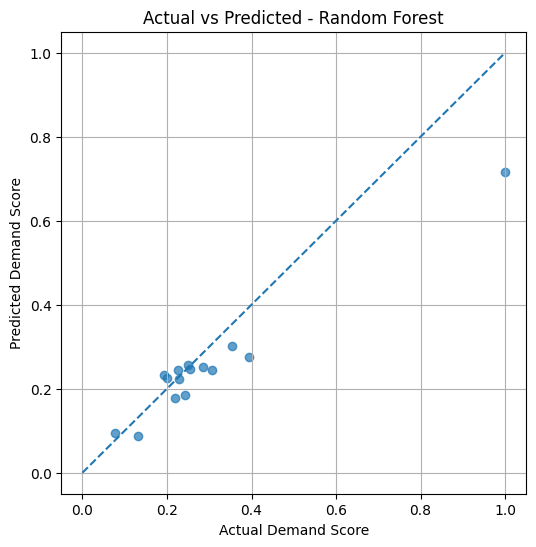

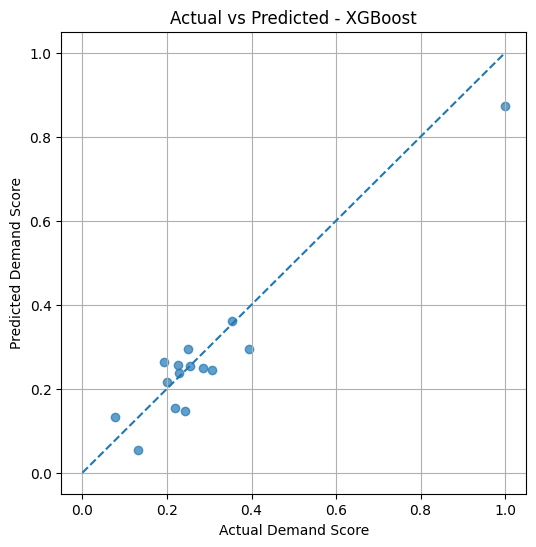

In [16]:
# =========================================================
# ACTUAL VS PREDICTED PLOTS
# =========================================================

for name, pred in all_predictions.items():
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, pred, alpha=0.7)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Actual Demand Score")
    plt.ylabel("Predicted Demand Score")
    plt.title(f"Actual vs Predicted - {name}")
    plt.grid(True)
    plt.show()

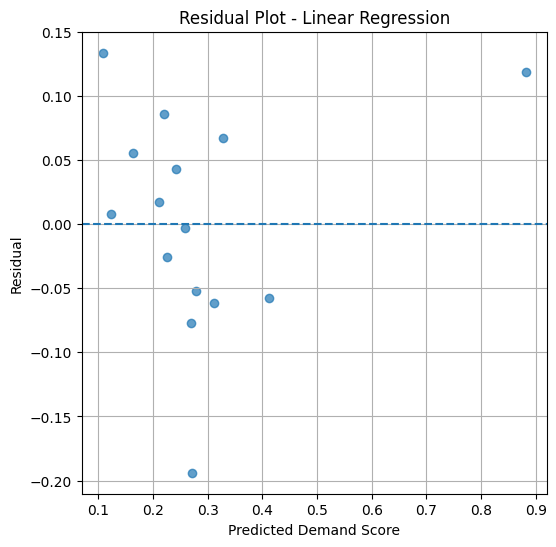

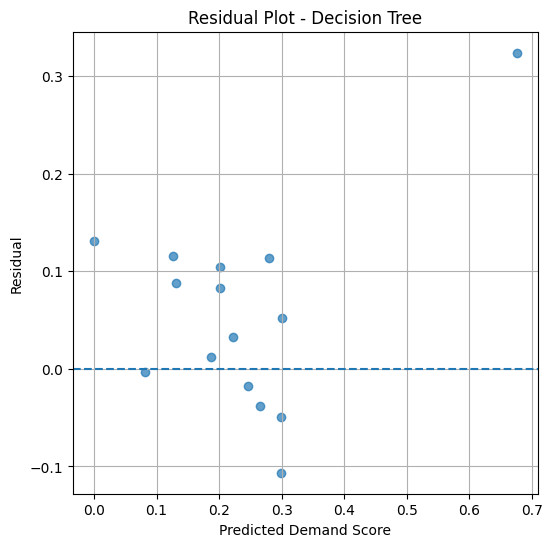

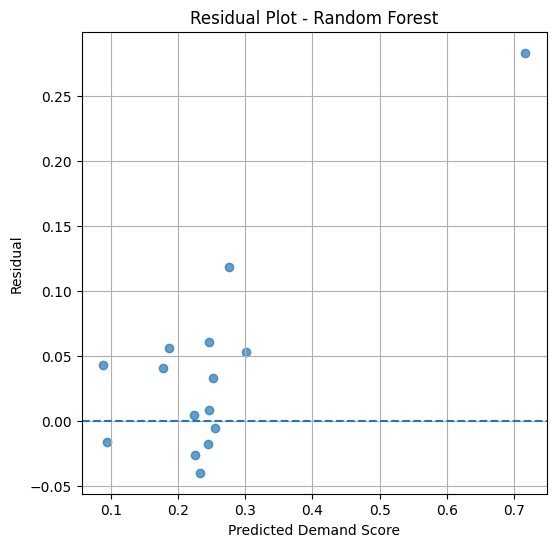

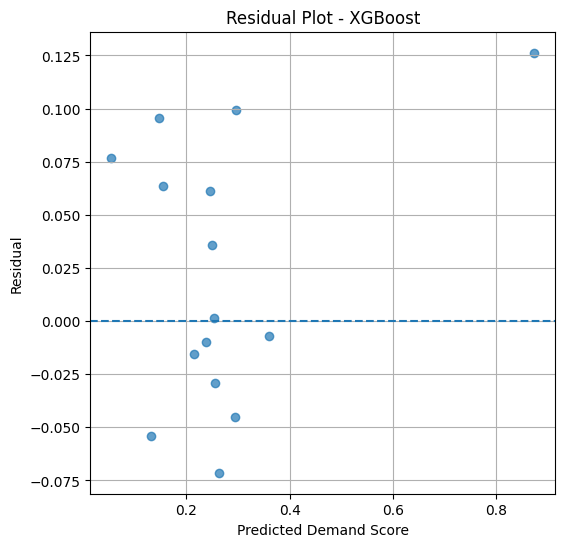

In [17]:
# =========================================================
# RESIDUAL PLOTS
# =========================================================

for name, pred in all_predictions.items():
    residuals = y_test.values - pred

    plt.figure(figsize=(6, 6))
    plt.scatter(pred, residuals, alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Demand Score")
    plt.ylabel("Residual")
    plt.title(f"Residual Plot - {name}")
    plt.grid(True)
    plt.show()


=== FEATURE IMPORTANCE: Decision Tree ===


,Feature,Importance
8,historical_crime_count,0.638480
1,gn_population,0.134999
7,Land_Area_Density,0.079534
5,Building_Density,0.051015
2,gn_distance_m,0.049954
4,Unemployment_Rate,0.014559
9,crime_type_diversity,0.011441
3,Avg_Household_Income,0.011028
6,Road_Density,0.004771
10,holiday_crime_ratio,0.003715


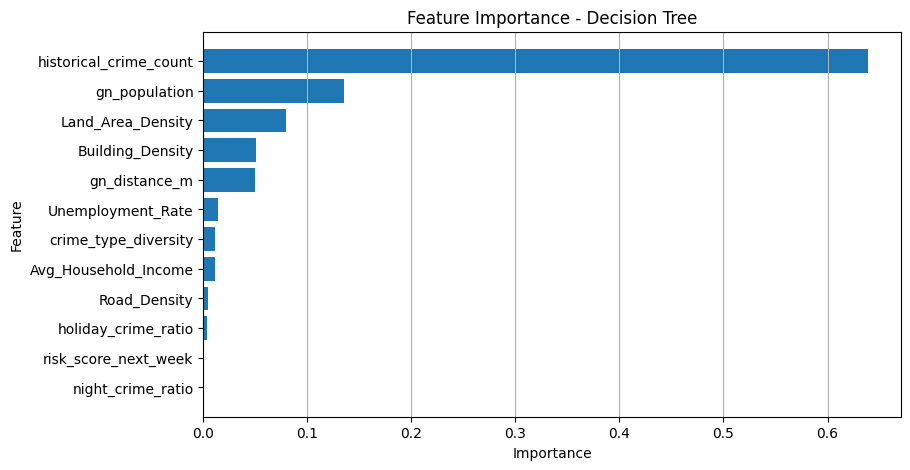


=== FEATURE IMPORTANCE: Random Forest ===


,Feature,Importance
8,historical_crime_count,0.303568
0,risk_score_next_week,0.276284
1,gn_population,0.143359
7,Land_Area_Density,0.078273
5,Building_Density,0.052525
2,gn_distance_m,0.047252
4,Unemployment_Rate,0.026315
6,Road_Density,0.022531
3,Avg_Household_Income,0.017797
11,night_crime_ratio,0.013360


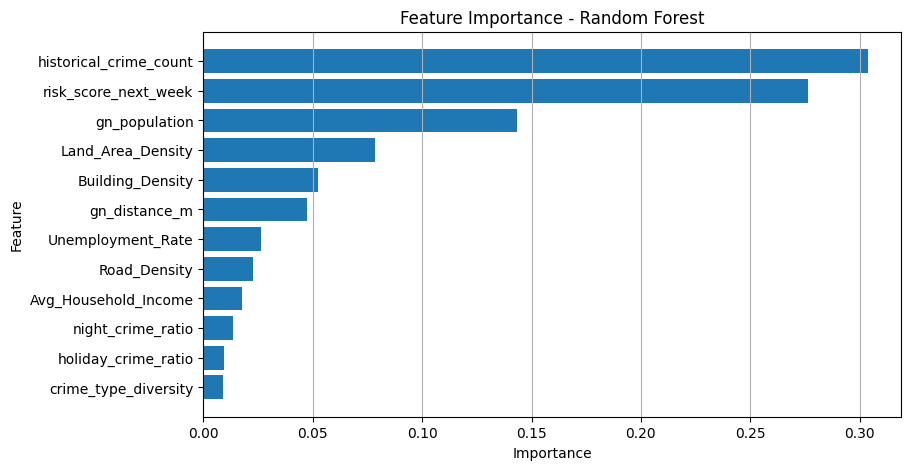


=== FEATURE IMPORTANCE: XGBoost ===


,Feature,Importance
0,risk_score_next_week,0.298595
8,historical_crime_count,0.201725
7,Land_Area_Density,0.107855
9,crime_type_diversity,0.084053
5,Building_Density,0.078870
1,gn_population,0.068525
6,Road_Density,0.047893
2,gn_distance_m,0.030577
3,Avg_Household_Income,0.027655
10,holiday_crime_ratio,0.023834


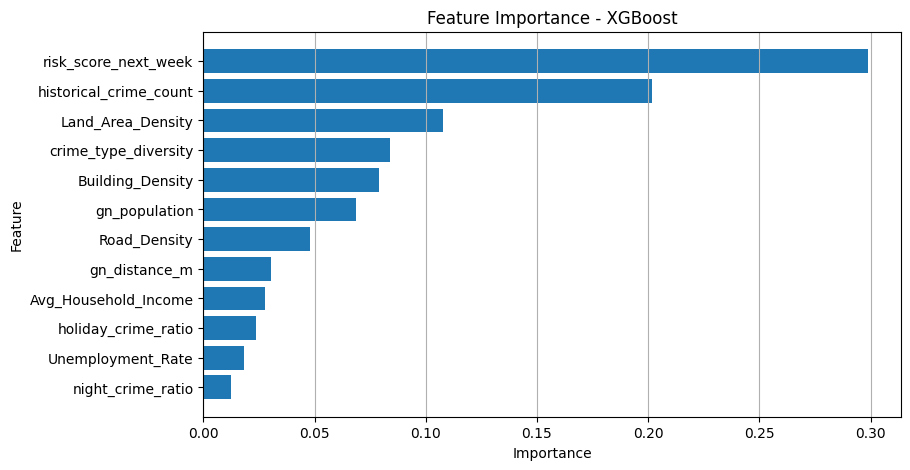

In [18]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

tree_models = {
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
    "XGBoost": models["XGBoost"]
}

for name, model in tree_models.items():
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    print(f"\n=== FEATURE IMPORTANCE: {name} ===")
    display(importance_df)

    plt.figure(figsize=(9, 5))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.title(f"Feature Importance - {name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()
    plt.grid(True, axis="x")
    plt.show()

In [19]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model based on R2:", best_model_name)

Best model based on R2: XGBoost
